# Notebook 3 — Modèle ML Baseline
## Données : MODIS NDVI + FAO Rendements
## Zone : Mandoul, Tchad | Période : 2019-2023
### Objectif : entraîner un modèle de prédiction de rendement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import LeaveOneOut

In [2]:
df = pd.read_csv('dataset_ml_3régions_V2.csv')
print(df.shape)
print(df)

(36, 11)
    annee             region  evi_max  evi_mean  evi_min  evi_integral  \
0    2010  Logone-Occidental   0.4873  0.355709   0.2322        3.9128   
1    2010            Mandoul   0.5110  0.407825   0.2284        4.8939   
2    2010        Moyen-Chari   0.5609  0.413442   0.2637        4.9613   
3    2011  Logone-Occidental   0.5083  0.373958   0.2215        4.4875   
4    2011            Mandoul   0.5945  0.462462   0.2715        6.0120   
5    2011        Moyen-Chari   0.6132  0.429969   0.2157        5.5896   
6    2013  Logone-Occidental   0.4435  0.356430   0.2160        3.5643   
7    2013            Mandoul   0.4861  0.411064   0.2588        4.5217   
8    2013        Moyen-Chari   0.5480  0.408585   0.2053        5.3116   
9    2014  Logone-Occidental   0.4657  0.344600   0.1864        4.4798   
10   2014            Mandoul   0.5147  0.370309   0.1994        4.0734   
11   2014        Moyen-Chari   0.5174  0.396927   0.2426        4.3662   
12   2015  Logone-Occidental 

## Encoder la colonne région

In [3]:
df_encoded = pd.get_dummies(df, columns=['region'])
print(df_encoded.columns.tolist())
print(df_encoded.shape)

['annee', 'evi_max', 'evi_mean', 'evi_min', 'evi_integral', 'evi_mean_vg', 'evi_max_fl', 'evi_mean_sn', 'pluie_saison_mm', 'rendement_t_ha', 'region_Logone-Occidental', 'region_Mandoul', 'region_Moyen-Chari']
(36, 13)


In [4]:
X = df_encoded.drop(columns=['annee', 'rendement_t_ha'])
y = df_encoded['rendement_t_ha']

print("Shape X :", X.shape)
print("Shape y :", y.shape)
print("\nFeatures :", X.columns.tolist())

Shape X : (36, 11)
Shape y : (36,)

Features : ['evi_max', 'evi_mean', 'evi_min', 'evi_integral', 'evi_mean_vg', 'evi_max_fl', 'evi_mean_sn', 'pluie_saison_mm', 'region_Logone-Occidental', 'region_Mandoul', 'region_Moyen-Chari']


# Entraîner le modèle avec Leave-One-Out

In [5]:
annees = df_encoded['annee'].values
annees_uniques = sorted(df_encoded['annee'].unique())

model = RandomForestRegressor(n_estimators=100, random_state=42)
y_reel = []
y_predit = []
annees_testees = []

for annee_test in annees_uniques:
    # Séparer train et test par année
    mask_test  = annees == annee_test
    mask_train = annees != annee_test

    X_train = X[mask_train]
    X_test  = X[mask_test]
    y_train = y[mask_train]
    y_test  = y[mask_test]

    # Entraîner et prédire
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # Sauvegarder
    y_reel.extend(y_test.values)
    y_predit.extend(predictions)
    annees_testees.extend([annee_test] * len(y_test))

print("✅ Entraînement terminé !")
print(f"Nombre de prédictions : {len(y_predit)}")

✅ Entraînement terminé !
Nombre de prédictions : 36


## Evaluation des performances

In [6]:
y_reel_arr   = np.array(y_reel)
y_predit_arr = np.array(y_predit)

rmse = np.sqrt(np.mean((y_reel_arr - y_predit_arr)**2))
mape = np.mean(np.abs((y_reel_arr - y_predit_arr) / y_reel_arr)) * 100
biais = np.mean(y_predit_arr - y_reel_arr)

print(f"RMSE  : {rmse:.4f} t/ha")
print(f"MAPE  : {mape:.2f} %")
print(f"Biais : {biais:.4f} t/ha")

RMSE  : 0.0688 t/ha
MAPE  : 7.91 %
Biais : 0.0042 t/ha


## Visualisation des résultats

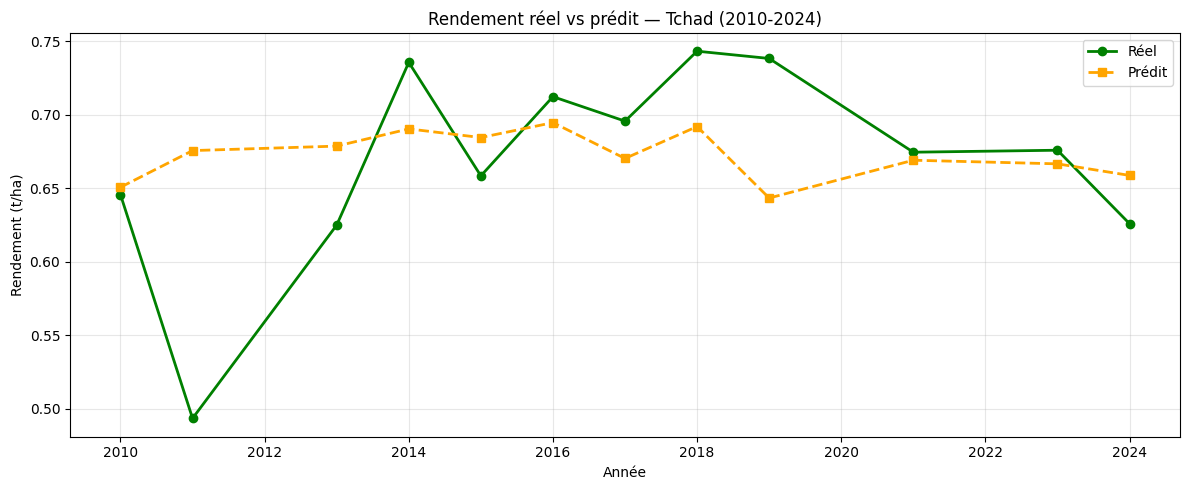

In [7]:
df_resultats = pd.DataFrame({
    'annee'   : annees_testees,
    'reel'    : y_reel,
    'predit'  : y_predit
}).groupby('annee').mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(df_resultats['annee'], df_resultats['reel'],
         'o-', color='green', linewidth=2, label='Réel')
plt.plot(df_resultats['annee'], df_resultats['predit'],
         's--', color='orange', linewidth=2, label='Prédit')
plt.title('Rendement réel vs prédit — Tchad (2010-2024)')
plt.xlabel('Année')
plt.ylabel('Rendement (t/ha)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('resultats_modele_v2.png', dpi=150)
plt.show()

In [8]:
import joblib

joblib.dump(model, 'modele_rendement_v2.pkl')
print("✅ Modèle sauvegardé !")

# Sauvegarder aussi les résultats
df_resultats.to_csv('resultats_predictions_v2.csv', index=False)
print("✅ Résultats sauvegardés !")

✅ Modèle sauvegardé !
✅ Résultats sauvegardés !
